# 06 — XGBRegressor with Walk-Forward Cross-Validation

**Changes vs original (which was empty):**

Same walk-forward structure as `05_model` but using `XGBRegressor` on raw `target_1m`
instead of the binned rank target. This gives a second independent signal that can be
ensembled with the ranker.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from xgboost import XGBRegressor


## 1. Load

In [2]:
monthly = pd.read_csv(
    r"C:\Users\naksh\Projects\xgboost_stock_ranking\data\model_data.csv",
    parse_dates=["Date"]
)

with open(r"C:\Users\naksh\Projects\xgboost_stock_ranking\data\processed\feature_cols.json") as f:
    feature_cols = json.load(f)

monthly = monthly.sort_values(["Date", "SecuritiesCode"]).reset_index(drop=True)

print("Shape:", monthly.shape, "  Features:", len(feature_cols))
print("Date range:", monthly["Date"].min().date(), "→", monthly["Date"].max().date())

Shape: (114554, 65)   Features: 54
Date range: 2017-01-31 → 2021-11-30


## 2. Walk-forward fold definitions

Identical fold structure as `05_model` so OOS periods match exactly.

In [3]:
MIN_TRAIN_MONTHS = 36
TEST_FOLD_MONTHS = 6
GAP_MONTHS       = 1

all_months = sorted(monthly["Date"].dt.to_period("M").unique())

folds = []
fold_start_idx = MIN_TRAIN_MONTHS

while fold_start_idx + GAP_MONTHS < len(all_months):
    train_end_period  = all_months[fold_start_idx - 1]
    test_start_period = all_months[fold_start_idx + GAP_MONTHS]
    test_end_idx      = min(fold_start_idx + GAP_MONTHS + TEST_FOLD_MONTHS - 1, len(all_months) - 1)
    test_end_period   = all_months[test_end_idx]

    folds.append({
        "train_end":  train_end_period.to_timestamp(how="end"),
        "test_start": test_start_period.to_timestamp(how="start"),
        "test_end":   test_end_period.to_timestamp(how="end"),
    })

    fold_start_idx += TEST_FOLD_MONTHS

print(f"{len(folds)} folds:")
for i, f in enumerate(folds):
    print(f"  Fold {i}: train ≤ {f['train_end'].date()}  |  "
          f"test {f['test_start'].date()} → {f['test_end'].date()}")

4 folds:
  Fold 0: train ≤ 2019-12-31  |  test 2020-02-01 → 2020-07-31
  Fold 1: train ≤ 2020-06-30  |  test 2020-08-01 → 2021-01-31
  Fold 2: train ≤ 2020-12-31  |  test 2021-02-01 → 2021-07-31
  Fold 3: train ≤ 2021-06-30  |  test 2021-08-01 → 2021-11-30


## 3. Walk-forward training loop

In [4]:
target_col = "target_1m"

all_test_predictions = []
fold_importances     = []

for fold_idx, fold in enumerate(folds):

    train_df = monthly[monthly["Date"] <= fold["train_end"]].copy()
    test_df  = monthly[
        (monthly["Date"] >= fold["test_start"]) &
        (monthly["Date"] <= fold["test_end"])
    ].copy()

    if len(train_df) == 0 or len(test_df) == 0:
        continue

    val_cutoff  = train_df["Date"].max() - pd.DateOffset(months=6)
    inner_train = train_df[train_df["Date"] <= val_cutoff]
    inner_valid = train_df[train_df["Date"] >  val_cutoff]

    X_tr, y_tr = inner_train[feature_cols], inner_train[target_col]
    X_va, y_va = inner_valid[feature_cols], inner_valid[target_col]
    X_te       = test_df[feature_cols]

    regressor = XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        learning_rate=0.05,
        n_estimators=1000,
        max_depth=6,
        min_child_weight=30,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        early_stopping_rounds=50,
        random_state=42,
    )

    regressor.fit(
        X_tr, y_tr,
        eval_set=[(X_tr, y_tr), (X_va, y_va)],
        verbose=False,
    )

    test_df = test_df.copy()
    test_df["score"] = regressor.predict(X_te)
    test_df["fold"]  = fold_idx

    all_test_predictions.append(test_df[["Date", "SecuritiesCode", "target_1m", "score", "fold"]])
    fold_importances.append(regressor.feature_importances_)

    fold_ic = (
        test_df.groupby("Date")
               .apply(lambda x: spearmanr(x["score"], x["target_1m"]).correlation,
                      include_groups=False)
    )
    print(f"Fold {fold_idx}: best_iter={regressor.best_iteration}  "
          f"mean_IC={fold_ic.mean():.4f}  IC>0={(fold_ic > 0).mean():.0%}")

oos = pd.concat(all_test_predictions, ignore_index=True)
print(f"\nTotal OOS rows: {len(oos):,}")

Fold 0: best_iter=0  mean_IC=0.0627  IC>0=67%
Fold 1: best_iter=30  mean_IC=0.0297  IC>0=83%
Fold 2: best_iter=4  mean_IC=-0.0083  IC>0=50%
Fold 3: best_iter=5  mean_IC=-0.0287  IC>0=25%

Total OOS rows: 43,791


## 4. Aggregate OOS evaluation

In [5]:
monthly_ic = (
    oos.groupby("Date")
       .apply(lambda x: spearmanr(x["score"], x["target_1m"]).correlation,
              include_groups=False)
)

icir = monthly_ic.mean() / (monthly_ic.std() + 1e-8)

print("=== OOS IC Summary (all folds combined) ===")
print(monthly_ic.describe())
print(f"\nMean IC  : {monthly_ic.mean():.4f}")
print(f"ICIR     : {icir:.4f}")
print(f"IC > 0   : {(monthly_ic > 0).mean():.2%}")

=== OOS IC Summary (all folds combined) ===
count    22.000000
mean      0.017720
std       0.096318
min      -0.167349
25%      -0.050458
50%       0.016733
75%       0.083678
max       0.213302
dtype: float64

Mean IC  : 0.0177
ICIR     : 0.1840
IC > 0   : 59.09%


## 5. Long-short portfolio

In [6]:
def long_short_return(df):
    df = df.sort_values("score")
    n  = max(1, int(len(df) * 0.10))
    return df.iloc[-n:]["target_1m"].mean() - df.iloc[:n]["target_1m"].mean()

portfolio = oos.groupby("Date").apply(long_short_return, include_groups=False)

print(portfolio.describe())
print(f"\nAverage monthly L/S return : {portfolio.mean():.4%}")
print(f"Annualised Sharpe (approx) : {portfolio.mean() / portfolio.std() * np.sqrt(12):.2f}")

count    22.000000
mean      0.012762
std       0.029405
min      -0.032333
25%      -0.000861
50%       0.012509
75%       0.022857
max       0.084450
dtype: float64

Average monthly L/S return : 1.2762%
Annualised Sharpe (approx) : 1.50


## 6. Equity curve and IC series

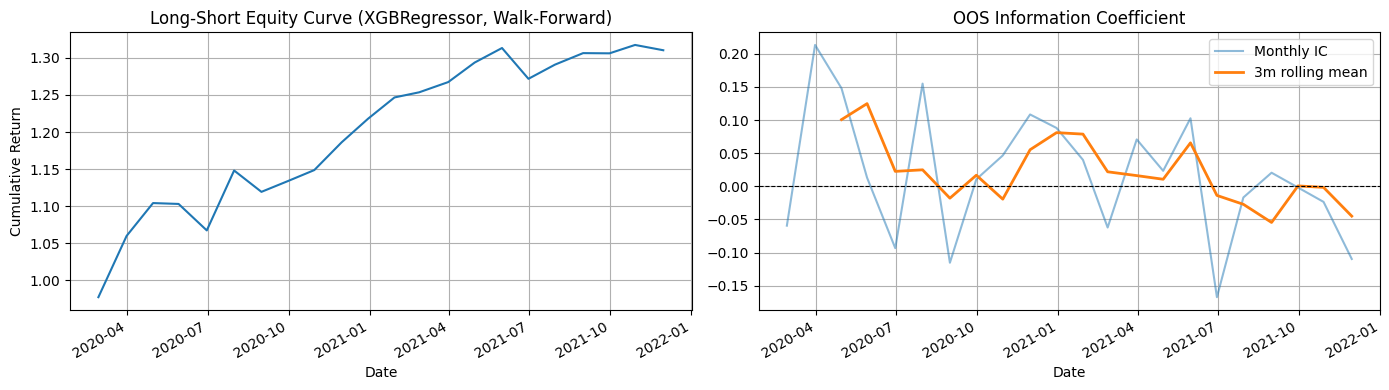

In [7]:
equity = (1 + portfolio).cumprod()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

equity.plot(ax=axes[0], title="Long-Short Equity Curve (XGBRegressor, Walk-Forward)")
axes[0].set_ylabel("Cumulative Return")
axes[0].grid(True)

monthly_ic.plot(ax=axes[1], alpha=0.5, label="Monthly IC")
monthly_ic.rolling(3).mean().plot(ax=axes[1], label="3m rolling mean", linewidth=2)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("OOS Information Coefficient")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 7. Averaged feature importance across folds

Top 20 features (avg across folds):
vol_12m                   0.074521
earnings_yield            0.036475
skew_12m                  0.031650
forecast_eps_growth       0.028872
forecast_profit_growth    0.026803
forecast_sales_growth     0.024363
asset_turnover            0.023799
Equity                    0.022812
vol_6m                    0.022546
log_market_cap            0.022265
mom_12m                   0.021474
price_to_earnings         0.021252
q_Profit_yoy              0.020750
q_NetSales                0.020563
mom_3m                    0.020460
NetSales                  0.018534
max_return_3m             0.018318
ma_12m_ratio              0.018259
vol_3m                    0.018133
profit_to_assets          0.017993
dtype: float32


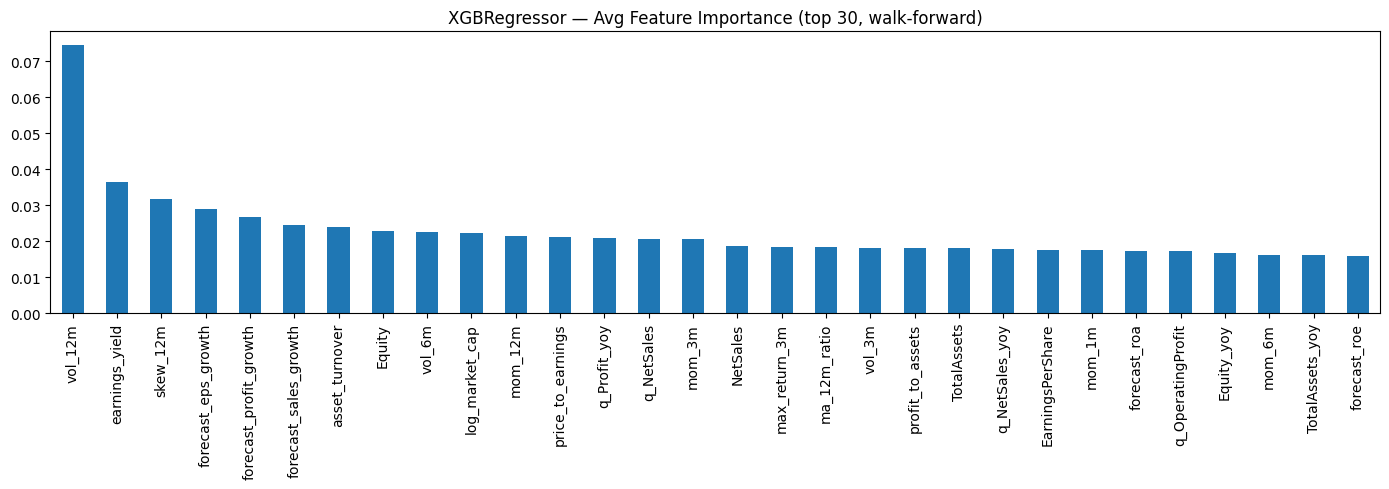

Saved: feature_importance_regressor.csv


In [8]:
avg_importance = (
    pd.Series(
        np.mean(fold_importances, axis=0),
        index=feature_cols
    )
    .sort_values(ascending=False)
)

print("Top 20 features (avg across folds):")
print(avg_importance.head(20))

avg_importance.head(30).plot(
    kind="bar", figsize=(14, 5),
    title="XGBRegressor — Avg Feature Importance (top 30, walk-forward)"
)
plt.tight_layout()
plt.show()

avg_importance.reset_index().rename(
    columns={"index": "feature", 0: "importance"}
).to_csv(r"C:\Users\naksh\Projects\xgboost_stock_ranking\data\feature_importance_regressor.csv", index=False)
print("Saved: feature_importance_regressor.csv")